# Ensemble Learning – Assignment
**Topics covered:** Bagging, Random Forest, Boosting basics, Stacking, OOB Score, Feature Importance

# Part A: Theoretical Questions

### 1. Can we use Bagging for regression problems?
Yes. Bagging (Bootstrap Aggregating) works for both classification and regression. For regression, instead of taking a majority vote across the base models, we take the **average** of the predictions from all the base estimators (e.g., `BaggingRegressor` in scikit-learn).

### 2. What is the difference between multiple model training and single model training?
- **Single model training:** One model is trained on the entire dataset, and its prediction is final. It can be sensitive to noise and prone to overfitting or underfitting depending on its complexity.
- **Multiple model training (ensemble):** Several models (same or different algorithms) are trained, usually on different subsets of data or features, and their predictions are combined (voting/averaging/stacking). This generally reduces variance, reduces bias (in boosting), and improves generalization compared to a single model.

### 3. Explain the concept of feature randomness in Random Forest.
In a Random Forest, at every split in every tree, instead of considering **all** features to find the best split, only a **random subset of features** (`max_features`) is considered. This is called feature randomness/feature bagging. It de-correlates the individual trees (since they no longer all rely on the same dominant features), which reduces the variance of the overall ensemble and improves generalization.

### 4. What is OOB (Out-of-Bag) Score?
When bootstrap sampling is used to train each base estimator, on average about **63%** of the original samples are used (with repetition) for each tree, leaving roughly **37%** of the samples unused — these are called **Out-of-Bag (OOB)** samples for that tree. The OOB score is computed by predicting each sample using only the trees that did **not** see it during training, and comparing it with the true label. This gives an unbiased estimate of model performance **without needing a separate validation set**.

### 5. How can you measure the importance of features in a Random Forest model?
Common ways:
1. **Mean Decrease in Impurity (MDI)** – the default `feature_importances_` in scikit-learn; it averages the total reduction in Gini impurity (or entropy/variance) brought by a feature across all trees, weighted by the number of samples it splits.
2. **Permutation Importance** – randomly shuffle a feature's values and measure the drop in model performance (more reliable, avoids bias toward high-cardinality features).
3. **Drop-Column Importance** – retrain the model without a feature and measure the change in score (expensive but accurate).

### 6. Explain the working principle of a Bagging Classifier.
1. Create multiple **bootstrap samples** (random sampling with replacement) from the training data.
2. Train an independent **base classifier** (often a Decision Tree) on each bootstrap sample.
3. For prediction, each base classifier votes, and the **majority class** is chosen as the final prediction (hard voting), or probabilities are averaged (soft voting).
This reduces variance because errors of individual high-variance models tend to average out.

### 7. How do you evaluate a Bagging Classifier's performance?
Same metrics as any classifier:
- **Accuracy**, **Precision**, **Recall**, **F1-score**
- **Confusion Matrix**
- **ROC-AUC score**
- **Cross-validation** scores
- **OOB score** (if `oob_score=True` and bootstrap sampling is used)

### 8. How does a Bagging Regressor work?
It works exactly like the Bagging Classifier, except:
1. Multiple bootstrap samples are created.
2. A regressor (e.g., Decision Tree Regressor) is trained on each sample.
3. The final prediction is the **average (mean)** of all the individual regressors' predictions, rather than a majority vote.

### 9. What is the main advantage of ensemble techniques?
Ensembles combine multiple "weak" or diverse models to produce a model that generally has **better accuracy, lower variance, and better generalization** than any single constituent model. They are typically more robust to noise and overfitting.

### 10. What is the main challenge of ensemble methods?
- **Reduced interpretability** – harder to explain than a single model (e.g., one decision tree).
- **Higher computational cost** (more memory, more training/prediction time).
- Diminishing returns / risk of all models making correlated errors if base learners are too similar.

### 11. Explain the key idea behind ensemble techniques.
The key idea is **"wisdom of the crowd"** — instead of relying on a single model's prediction, combine the predictions of multiple models. As long as the individual models are reasonably accurate and make **different/independent errors**, combining them statistically reduces the overall error (variance and/or bias), producing a stronger overall predictor.

### 12. What is a Random Forest Classifier?
A Random Forest Classifier is an ensemble of **Decision Trees**, where each tree is trained on a different bootstrap sample of the data (bagging) and considers only a **random subset of features** at each split (feature randomness). The final classification is decided by **majority voting** across all the trees.

### 13. What are the main types of ensemble techniques?
1. **Bagging (Bootstrap Aggregating)** – e.g., Random Forest, Bagging Classifier/Regressor — reduces variance.
2. **Boosting** – e.g., AdaBoost, Gradient Boosting, XGBoost, CatBoost — sequentially corrects errors of previous models, reduces bias.
3. **Stacking (Stacked Generalization)** – combines predictions of different base models using a meta-model.
4. **Voting** – simple averaging/majority vote of multiple different model types.

### 14. What is ensemble learning in machine learning?
Ensemble learning is a technique where **multiple individual models (learners)** are strategically combined to solve the same problem and produce a single, more powerful predictive model than any of the constituent models alone.

### 15. When should we avoid using ensemble methods?
- When **model interpretability** is critical (e.g., regulatory/medical settings requiring transparent decision rules).
- When **computational resources or latency constraints** are tight (real-time systems with limited inference budget).
- When the dataset is very **small**, since ensembles (especially boosting) can overfit or simply not provide enough benefit to justify the complexity.
- When a single well-tuned model already achieves near-optimal performance.

### 16. How does Bagging help in reducing overfitting?
Bagging trains each base model on a different bootstrap sample, so each model overfits to *different* noise patterns in the data. When predictions are averaged/voted across many such models, these uncorrelated errors **cancel out**, lowering the overall variance of the ensemble without increasing bias much — this directly combats overfitting, especially for high-variance models like deep decision trees.

### 17. Why is Random Forest better than a single Decision Tree?
- A single Decision Tree tends to **overfit** the training data (high variance, low bias).
- Random Forest averages many de-correlated trees (via bagging + feature randomness), which **reduces variance** while keeping bias low.
- It is generally more **robust to noise and outliers**, and gives more stable, generalizable predictions, plus it provides feature importance estimates.

### 18. What is the role of bootstrap sampling in Bagging?
Bootstrap sampling (random sampling **with replacement**) creates multiple different training subsets from the original dataset. This **introduces diversity** among the base learners, since each one sees a slightly different version of the data, which is essential for the variance-reduction benefit of bagging to work.

### 19. What are some real-world applications of ensemble techniques?
- **Credit scoring / fraud detection** (Random Forest, XGBoost)
- **Medical diagnosis** (e.g., cancer classification using Random Forest)
- **Recommendation systems** (Gradient Boosting based ranking models)
- **Search engine ranking** (e.g., LambdaMART, a boosting algorithm)
- **Kaggle competitions** – Gradient Boosting (XGBoost, LightGBM, CatBoost) dominate tabular-data competitions.
- **Image classification ensembles**, **stock market prediction**, **customer churn prediction**.

### 20. What is the difference between Bagging and Boosting?

| Aspect | Bagging | Boosting |
|---|---|---|
| Training | Models trained **independently/parallel** on bootstrap samples | Models trained **sequentially**, each correcting errors of the previous |
| Goal | Reduce **variance** | Reduce **bias** (and variance) |
| Sample weighting | All samples weighted equally | Misclassified samples get **higher weight** in next iteration |
| Combination | Simple averaging / majority voting | Weighted sum of predictions |
| Overfitting risk | Lower | Higher (can overfit if not regularized) |
| Examples | Random Forest, Bagging Classifier | AdaBoost, Gradient Boosting, XGBoost, CatBoost |


# Part B: Practical Questions

We will use scikit-learn's **Breast Cancer dataset** (classification) and a **synthetic regression dataset** (`make_regression`) for the regression-based tasks. Common imports and dataset preparation are done first.

In [1]:
# Common Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, make_regression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor,
                               RandomForestClassifier, RandomForestRegressor,
                               StackingClassifier)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (accuracy_score, mean_squared_error, precision_score,
                              recall_score, f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, PrecisionRecallDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Classification dataset: Breast Cancer
data = load_breast_cancer()
Xc = pd.DataFrame(data.data, columns=data.feature_names)
yc = data.target
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)

# Regression dataset: synthetic
Xr, yr = make_regression(n_samples=500, n_features=10, noise=15, random_state=RANDOM_STATE)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

print("Classification train/test shapes:", Xc_train.shape, Xc_test.shape)
print("Regression train/test shapes:", Xr_train.shape, Xr_test.shape)


Classification train/test shapes: (455, 30) (114, 30)
Regression train/test shapes: (400, 10) (100, 10)


### Q21. Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy.

In [2]:
bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                            n_estimators=50, random_state=RANDOM_STATE)
bag_clf.fit(Xc_train, yc_train)
pred = bag_clf.predict(Xc_test)
print("Bagging Classifier Accuracy:", accuracy_score(yc_test, pred))


Bagging Classifier Accuracy: 0.9385964912280702


### Q22. Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE).

In [3]:
bag_reg = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
                           n_estimators=50, random_state=RANDOM_STATE)
bag_reg.fit(Xr_train, yr_train)
pred = bag_reg.predict(Xr_test)
print("Bagging Regressor MSE:", mean_squared_error(yr_test, pred))


Bagging Regressor MSE: 4458.2962429028485


### Q23. Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores.

In [4]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_clf.fit(Xc_train, yc_train)

importances = pd.Series(rf_clf.feature_importances_, index=Xc.columns).sort_values(ascending=False)
print(importances)


worst area                 0.140016
worst concave points       0.129530
worst radius               0.097696
mean concave points        0.090885
worst perimeter            0.072226
mean perimeter             0.069574
mean radius                0.068676
mean concavity             0.057638
mean area                  0.049172
worst concavity            0.034340
area error                 0.033104
worst compactness          0.018600
worst texture              0.018597
radius error               0.016770
worst smoothness           0.012436
mean compactness           0.011715
perimeter error            0.009633
mean texture               0.009584
worst symmetry             0.008335
compactness error          0.005979
mean smoothness            0.005598
texture error              0.005214
worst fractal dimension    0.005166
mean symmetry              0.004666
mean fractal dimension     0.004489
fractal dimension error    0.004442
concavity error            0.004310
concave points error       0

### Q24. Train a Random Forest Regressor and compare its performance with a single Decision Tree.

In [5]:
dt_reg = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_reg.fit(Xr_train, yr_train)
dt_mse = mean_squared_error(yr_test, dt_reg.predict(Xr_test))

rf_reg = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_reg.fit(Xr_train, yr_train)
rf_mse = mean_squared_error(yr_test, rf_reg.predict(Xr_test))

print(f"Single Decision Tree MSE : {dt_mse:.3f}")
print(f"Random Forest MSE        : {rf_mse:.3f}")


Single Decision Tree MSE : 12039.540
Random Forest MSE        : 4279.665


### Q25. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier.

In [6]:
rf_oob = RandomForestClassifier(n_estimators=200, oob_score=True,
                                 bootstrap=True, random_state=RANDOM_STATE)
rf_oob.fit(Xc_train, yc_train)
print("OOB Score:", rf_oob.oob_score_)


OOB Score: 0.9604395604395605


### Q26. Train a Bagging Classifier using SVM as a base estimator and print accuracy.

In [7]:
bag_svm = BaggingClassifier(estimator=SVC(probability=True, random_state=RANDOM_STATE),
                            n_estimators=20, random_state=RANDOM_STATE)
bag_svm.fit(Xc_train, yc_train)
pred = bag_svm.predict(Xc_test)
print("Bagging (SVM base) Accuracy:", accuracy_score(yc_test, pred))


Bagging (SVM base) Accuracy: 0.9122807017543859


### Q27. Train a Random Forest Classifier with different numbers of trees and compare accuracy.

In [8]:
for n in [10, 50, 100, 200, 300]:
    rf = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
    rf.fit(Xc_train, yc_train)
    acc = accuracy_score(yc_test, rf.predict(Xc_test))
    print(f"n_estimators={n:<4} -> Accuracy = {acc:.4f}")


n_estimators=10   -> Accuracy = 0.9386
n_estimators=50   -> Accuracy = 0.9561


n_estimators=100  -> Accuracy = 0.9561


n_estimators=200  -> Accuracy = 0.9561


n_estimators=300  -> Accuracy = 0.9474


### Q28. Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score.

In [9]:
bag_lr = BaggingClassifier(estimator=LogisticRegression(max_iter=5000),
                           n_estimators=50, random_state=RANDOM_STATE)
bag_lr.fit(Xc_train, yc_train)
proba = bag_lr.predict_proba(Xc_test)[:, 1]
print("Bagging (Logistic Regression base) AUC Score:", roc_auc_score(yc_test, proba))


Bagging (Logistic Regression base) AUC Score: 0.9950396825396826


### Q29. Train a Random Forest Regressor and analyze feature importance scores.

feature_6    0.361035
feature_7    0.185151
feature_1    0.156157
feature_0    0.092228
feature_3    0.090772
feature_9    0.027808
feature_2    0.023469
feature_4    0.022849
feature_8    0.020797
feature_5    0.019731
dtype: float64


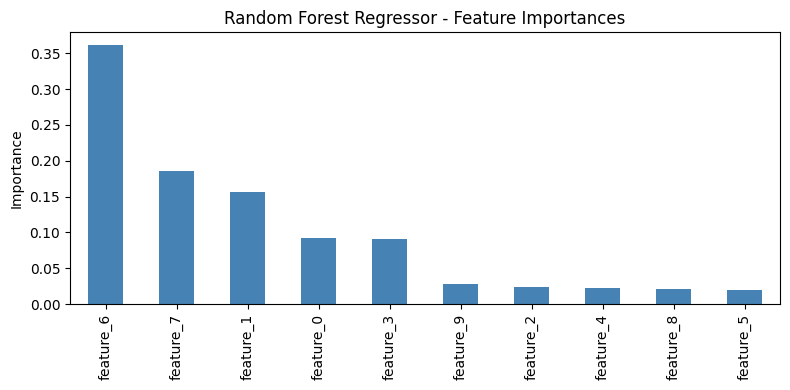

In [10]:
rf_reg2 = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_reg2.fit(Xr_train, yr_train)

feat_imp = pd.Series(rf_reg2.feature_importances_,
                      index=[f"feature_{i}" for i in range(Xr.shape[1])]).sort_values(ascending=False)
print(feat_imp)

plt.figure(figsize=(8,4))
feat_imp.plot(kind="bar", color="steelblue")
plt.title("Random Forest Regressor - Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


### Q30. Train an ensemble model using both Bagging and Random Forest and compare accuracy.

In [11]:
bag_final = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                              n_estimators=100, random_state=RANDOM_STATE)
bag_final.fit(Xc_train, yc_train)
bag_acc = accuracy_score(yc_test, bag_final.predict(Xc_test))

rf_final = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_final.fit(Xc_train, yc_train)
rf_acc = accuracy_score(yc_test, rf_final.predict(Xc_test))

print(f"Bagging Classifier Accuracy     : {bag_acc:.4f}")
print(f"Random Forest Classifier Accuracy: {rf_acc:.4f}")


Bagging Classifier Accuracy     : 0.9386
Random Forest Classifier Accuracy: 0.9561


### Q31. Train a Random Forest Classifier and tune hyperparameters using GridSearchCV.

In [12]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                     param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(Xc_train, yc_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
print("Test Accuracy with Best Estimator:", accuracy_score(yc_test, grid.best_estimator_.predict(Xc_test)))


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Best CV Accuracy: 0.9604395604395606
Test Accuracy with Best Estimator: 0.956140350877193


### Q32. Train a Bagging Regressor with different numbers of base estimators and compare performance.

In [13]:
for n in [10, 50, 100, 200]:
    breg = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
                             n_estimators=n, random_state=RANDOM_STATE)
    breg.fit(Xr_train, yr_train)
    mse = mean_squared_error(yr_test, breg.predict(Xr_test))
    print(f"n_estimators={n:<4} -> MSE = {mse:.3f}")


n_estimators=10   -> MSE = 5357.878


n_estimators=50   -> MSE = 4458.296


n_estimators=100  -> MSE = 4345.889


n_estimators=200  -> MSE = 4203.673


### Q33. Train a Random Forest Classifier and analyze misclassified samples.

In [14]:
rf_mis = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_mis.fit(Xc_train, yc_train)
preds = rf_mis.predict(Xc_test)

misclassified_idx = np.where(preds != yc_test)[0]
print(f"Number of misclassified samples: {len(misclassified_idx)} out of {len(yc_test)}")

misclassified_df = Xc_test.iloc[misclassified_idx].copy()
misclassified_df['true_label'] = np.array(yc_test)[misclassified_idx]
misclassified_df['predicted_label'] = preds[misclassified_idx]
misclassified_df.head()


Number of misclassified samples: 5 out of 114


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,true_label,predicted_label
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,117.20,1009.0,0.1338,0.1679,0.1663,0.09123,0.2394,0.06469,1,0
406,16.14,14.86,104.30,800.0,0.09495,0.08501,0.05500,0.04528,0.1735,0.05875,...,115.90,947.9,0.1206,0.1722,0.2310,0.11290,0.2778,0.07012,1,0
41,10.95,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,0.06870,...,87.22,514.0,0.1909,0.2698,0.4023,0.14240,0.2964,0.09606,0,1
73,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,...,110.30,812.4,0.1411,0.3542,0.2779,0.13830,0.2589,0.10300,0,1
385,14.60,23.29,93.97,664.7,0.08682,0.06636,0.08390,0.05271,0.1627,0.05416,...,102.20,758.2,0.1312,0.1581,0.2675,0.13590,0.2477,0.06836,0,1


### Q34. Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier.

In [15]:
dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_clf.fit(Xc_train, yc_train)
dt_acc = accuracy_score(yc_test, dt_clf.predict(Xc_test))

bag_clf2 = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                             n_estimators=100, random_state=RANDOM_STATE)
bag_clf2.fit(Xc_train, yc_train)
bag_acc2 = accuracy_score(yc_test, bag_clf2.predict(Xc_test))

print(f"Single Decision Tree Accuracy : {dt_acc:.4f}")
print(f"Bagging Classifier Accuracy   : {bag_acc2:.4f}")


Single Decision Tree Accuracy : 0.9123
Bagging Classifier Accuracy   : 0.9386


### Q35. Train a Random Forest Classifier and visualize the confusion matrix.

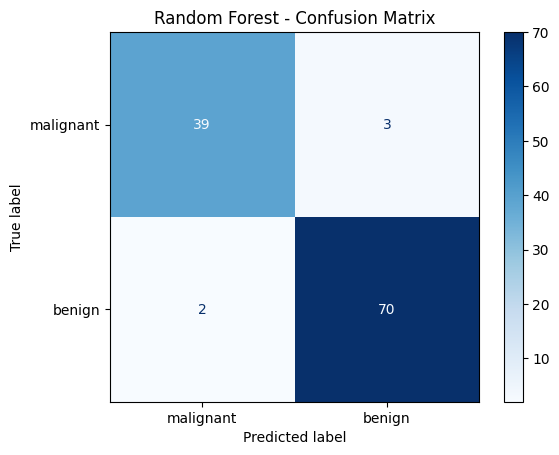

In [16]:
rf_cm = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_cm.fit(Xc_train, yc_train)
preds = rf_cm.predict(Xc_test)

cm = confusion_matrix(yc_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()


### Q36. Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy.

In [17]:
estimators = [
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
]
stack_clf = StackingClassifier(estimators=estimators,
                                final_estimator=LogisticRegression(max_iter=5000))
stack_clf.fit(Xc_train, yc_train)
stack_acc = accuracy_score(yc_test, stack_clf.predict(Xc_test))
print("Stacking Classifier Accuracy:", stack_acc)


Stacking Classifier Accuracy: 0.9210526315789473


### Q37. Train a Random Forest Classifier and print the top 5 most important features.

In [18]:
rf_top = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_top.fit(Xc_train, yc_train)

top5 = pd.Series(rf_top.feature_importances_, index=Xc.columns).sort_values(ascending=False).head(5)
print("Top 5 Most Important Features:")
print(top5)


Top 5 Most Important Features:
worst area              0.140016
worst concave points    0.129530
worst radius            0.097696
mean concave points     0.090885
worst perimeter         0.072226
dtype: float64


### Q38. Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score.

In [19]:
bag_eval = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                             n_estimators=100, random_state=RANDOM_STATE)
bag_eval.fit(Xc_train, yc_train)
preds = bag_eval.predict(Xc_test)

print("Precision:", precision_score(yc_test, preds))
print("Recall   :", recall_score(yc_test, preds))
print("F1-score :", f1_score(yc_test, preds))


Precision: 0.9452054794520548
Recall   : 0.9583333333333334
F1-score : 0.9517241379310345


### Q39. Train a Random Forest Classifier and analyze the effect of max_depth on accuracy.

max_depth=1     -> Accuracy = 0.9298


max_depth=2     -> Accuracy = 0.9474


max_depth=3     -> Accuracy = 0.9561


max_depth=5     -> Accuracy = 0.9561


max_depth=7     -> Accuracy = 0.9474


max_depth=10    -> Accuracy = 0.9561


max_depth=None  -> Accuracy = 0.9561


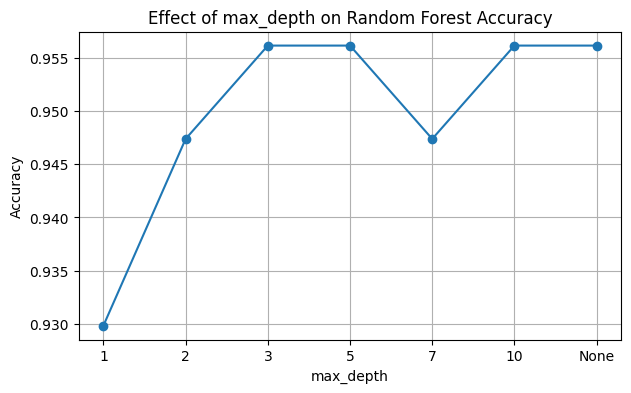

In [20]:
depths = [1, 2, 3, 5, 7, 10, None]
results = []
for d in depths:
    rf_d = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=RANDOM_STATE)
    rf_d.fit(Xc_train, yc_train)
    acc = accuracy_score(yc_test, rf_d.predict(Xc_test))
    results.append(acc)
    print(f"max_depth={str(d):<5} -> Accuracy = {acc:.4f}")

plt.figure(figsize=(7,4))
plt.plot([str(d) for d in depths], results, marker='o')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Effect of max_depth on Random Forest Accuracy")
plt.grid(True)
plt.show()


### Q40. Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare performance.

In [21]:
bag_dt = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
                          n_estimators=50, random_state=RANDOM_STATE)
bag_dt.fit(Xr_train, yr_train)
mse_dt = mean_squared_error(yr_test, bag_dt.predict(Xr_test))

bag_knn = BaggingRegressor(estimator=KNeighborsRegressor(),
                           n_estimators=50, random_state=RANDOM_STATE)
bag_knn.fit(Xr_train, yr_train)
mse_knn = mean_squared_error(yr_test, bag_knn.predict(Xr_test))

print(f"Bagging Regressor (Decision Tree base) MSE : {mse_dt:.3f}")
print(f"Bagging Regressor (KNeighbors base) MSE    : {mse_knn:.3f}")


Bagging Regressor (Decision Tree base) MSE : 4458.296
Bagging Regressor (KNeighbors base) MSE    : 4504.809


### Q41. Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score.

In [22]:
rf_auc = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_auc.fit(Xc_train, yc_train)
proba = rf_auc.predict_proba(Xc_test)[:, 1]
print("Random Forest ROC-AUC Score:", roc_auc_score(yc_test, proba))


Random Forest ROC-AUC Score: 0.9937169312169312


### Q42. Train a Bagging Classifier and evaluate its performance using cross-validation.

In [23]:
bag_cv = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                           n_estimators=50, random_state=RANDOM_STATE)
cv_scores = cross_val_score(bag_cv, Xc, yc, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross-validation scores: [0.9122807  0.92105263 0.98245614 0.95614035 1.        ]
Mean CV Accuracy: 0.9543859649122808


### Q43. Train a Random Forest Classifier and plot the Precision-Recall curve.

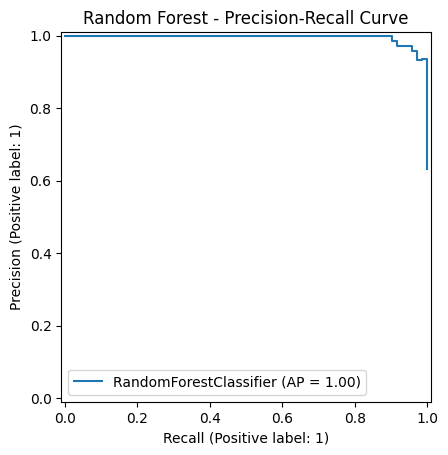

In [24]:
rf_pr = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_pr.fit(Xc_train, yc_train)

PrecisionRecallDisplay.from_estimator(rf_pr, Xc_test, yc_test)
plt.title("Random Forest - Precision-Recall Curve")
plt.show()


### Q44. Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy.

In [25]:
estimators2 = [('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))]
stack_clf2 = StackingClassifier(estimators=estimators2,
                                 final_estimator=LogisticRegression(max_iter=5000))
stack_clf2.fit(Xc_train, yc_train)
stack_acc2 = accuracy_score(yc_test, stack_clf2.predict(Xc_test))

rf_compare = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_compare.fit(Xc_train, yc_train)
rf_acc_compare = accuracy_score(yc_test, rf_compare.predict(Xc_test))

print(f"Stacking Classifier (RF + LogReg) Accuracy: {stack_acc2:.4f}")
print(f"Random Forest Classifier Accuracy         : {rf_acc_compare:.4f}")


Stacking Classifier (RF + LogReg) Accuracy: 0.9561
Random Forest Classifier Accuracy         : 0.9561


### Q45. Train a Bagging Regressor with different levels of bootstrap samples and compare performance.

In [26]:
for max_samp in [0.3, 0.5, 0.7, 1.0]:
    breg2 = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
                              n_estimators=50, max_samples=max_samp,
                              bootstrap=True, random_state=RANDOM_STATE)
    breg2.fit(Xr_train, yr_train)
    mse = mean_squared_error(yr_test, breg2.predict(Xr_test))
    print(f"max_samples={max_samp} -> MSE = {mse:.3f}")


max_samples=0.3 -> MSE = 5385.026


max_samples=0.5 -> MSE = 5155.557


max_samples=0.7 -> MSE = 5030.424


max_samples=1.0 -> MSE = 4458.296
